# Frustrated Magnets on a Quantum Annealer
### The Shastry–Sutherland lattice, magnetization plateaus, and defects

**Aritro Chatterjee** · Purdue University · Quantum Spin Lab

*Based on work with Hanjing Xu, Kevin Zhang, Yuxin Sun, Ammar Ali · Mentors: Arnab Banerjee, Erica Carlson*

---

Earlier today you used the annealer to solve optimization problems. Here we use the same tool for physics:
finding the lowest-energy arrangement of magnetic spins in a real material's lattice.

What we'll do (~15 min):
1. See what **frustration** means with just three spins
2. Build the **Shastry–Sutherland lattice** (the lattice of the real material SrCu₂(BO₃)₂)
3. Hand it to the annealer and look at the **ground state**
4. Turn up a magnetic field and watch **magnetization plateaus** appear
5. Break the lattice with **defects** and see the plateaus smear out

Everything runs locally with **simulated annealing** — no API key needed.

<a class="notebook-download"
   href="./downloads/frustrated_magnets_notebook.txt"
   download="Frustrated Magnets via Annealing.ipynb">
  Download notebook ↓
</a>

In [1]:
# If needed, install first:  %pip install dwave-ocean-sdk matplotlib
import itertools
import numpy as np
import matplotlib.pyplot as plt
import dimod

try:                                    # Ocean SDK's simulated annealer
    from dwave.samplers import SimulatedAnnealingSampler
except ImportError:                     # older installs ship it as "neal"
    from neal import SimulatedAnnealingSampler

sampler = SimulatedAnnealingSampler()
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Ready!")

Ready!


## 1. What is frustration?

Each magnetic atom carries a tiny magnet — a spin — that points up (**+1**) or down (**−1**).
In an antiferromagnet, neighbouring spins want to point opposite each other. The energy is

$$E = J\sum_{\langle i,j\rangle} s_i s_j \qquad (J>0)$$

so each pair pays **+J** if aligned and gains **−J** if opposite.

On a square that's easy: just alternate up, down, up, down. But put three spins on a triangle:
if spin 1 is up and spin 2 is down, spin 3 can't disagree with *both*. Someone is always unhappy.
That's **frustration**. Let's check every possibility:

In [ ]:
J = 1.0
bonds = [(0, 1), (1, 2), (0, 2)]              # the three edges of a triangle

states = list(itertools.product([+1, -1], repeat=3))  
energy = lambda s: sum(J * s[i] * s[j] for i, j in bonds)

for s in states:
    print(s, " energy =", energy(s))

E_min = min(energy(s) for s in states)
print(f"\nLowest energy = {E_min}, reached by {sum(energy(s)==E_min for s in states)} of 8 states")

(1, 1, 1)  energy = 3.0
(1, 1, -1)  energy = -1.0
(1, -1, 1)  energy = -1.0
(1, -1, -1)  energy = -1.0
(-1, 1, 1)  energy = -1.0
(-1, 1, -1)  energy = -1.0
(-1, -1, 1)  energy = -1.0
(-1, -1, -1)  energy = 3.0

Lowest energy = -1.0, reached by 6 of 8 states


6 of 8 states tie for the ground state. No single "best" answer — the system is degenerate.
Frustration is why these magnets are hard: huge numbers of near-equal configurations compete,
and that competition produces exotic phases like spin liquids and magnetization plateaus.
It's also exactly the kind of rugged energy landscape annealers are built to explore.

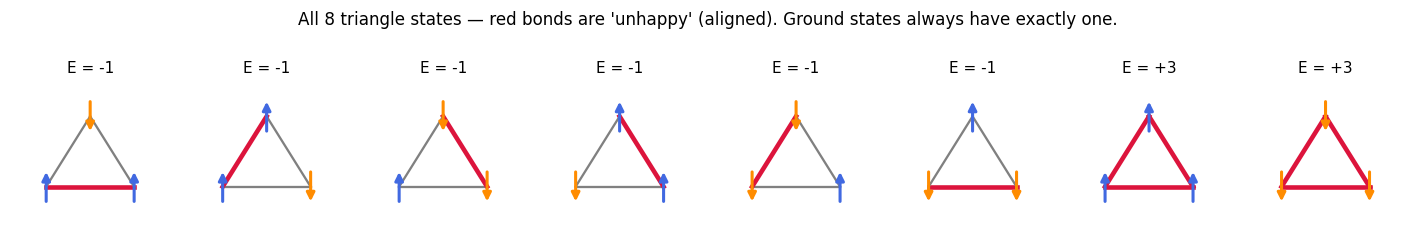

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(13, 2.1))
pos = np.array([[0, 0], [1, 0], [0.5, 0.87]])
for ax, s in zip(axes, sorted(states, key=energy)):
    for i, j in bonds:
        unhappy = s[i] == s[j]                         
        ax.plot(*pos[[i, j]].T, color="crimson" if unhappy else "grey", lw=3 if unhappy else 1.5)
    for p, spin in zip(pos, s):
        ax.annotate("", xy=p + [0, 0.22 * spin], xytext=p - [0, 0.22 * spin],
                    arrowprops=dict(arrowstyle="-|>", color="royalblue" if spin > 0 else "darkorange", lw=2))
    ax.set_title(f"E = {energy(s):+.0f}", fontsize=10)
    ax.set_xlim(-0.4, 1.4); ax.set_ylim(-0.4, 1.3); ax.axis("off")
fig.suptitle("All 8 triangle states — red bonds are 'unhappy' (aligned). Ground states always have exactly one.", fontsize=11)
plt.tight_layout(); plt.show()

## 2. The Shastry–Sutherland lattice

The real material **SrCu₂(BO₃)₂** arranges its magnetic copper atoms in a **Shastry–Sutherland lattice**:

* a square grid of bonds with strength **J₁**, plus
* extra diagonal "dimer" bonds with strength **J₂**, placed on every other square and alternating direction.

Squares + diagonals = triangles everywhere → frustration built into the lattice.

In [ ]:
def shastry_sutherland(L):
    # Bonds of an L x L Shastry-Sutherland lattice with periodic (wrap-around) edges.
    site = lambda x, y: (x % L) * L + (y % L)          
    J1_bonds, J2_bonds = [], []
    for x in range(L):
        for y in range(L):
            J1_bonds += [(site(x, y), site(x + 1, y)), (site(x, y), site(x, y + 1))]  # square grid
            if x % 2 == 0 and y % 2 == 0:              # "/" dimer on even squares
                J2_bonds.append((site(x, y), site(x + 1, y + 1)))
            if x % 2 == 1 and y % 2 == 1:              # "\" dimer on odd squares
                J2_bonds.append((site(x + 1, y), site(x, y + 1)))
    return J1_bonds, J2_bonds

L = 12
J1_bonds, J2_bonds = shastry_sutherland(L)
print(f"{L}x{L} lattice: {L*L} spins, {len(J1_bonds)} square bonds (J1), {len(J2_bonds)} dimer bonds (J2)")

12x12 lattice: 144 spins, 288 square bonds (J1), 72 dimer bonds (J2)


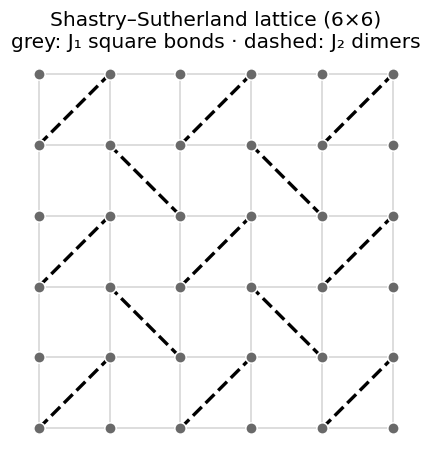

In [5]:
def draw_lattice(L, J1_bonds, J2_bonds, ax, spins=None):
    xy = lambda i: np.array(divmod(i, L))
    short = lambda a, b: np.abs(xy(a) - xy(b)).max() == 1   # skip wrap-around bonds when drawing
    for a, b in J1_bonds:
        if short(a, b): ax.plot(*np.array([xy(a), xy(b)]).T, color="lightgrey", lw=1, zorder=1)
    for a, b in J2_bonds:
        if short(a, b): ax.plot(*np.array([xy(a), xy(b)]).T, color="black", lw=2.2, ls="--", zorder=2)
    pts = np.array([xy(i) for i in range(L * L)])
    colors = "dimgrey" if spins is None else ["royalblue" if s > 0 else "darkorange" for s in spins]
    ax.scatter(*pts.T, c=colors, s=55, zorder=3, edgecolor="white")
    ax.set_aspect("equal"); ax.axis("off")

fig, ax = plt.subplots(figsize=(4.6, 4.6))
draw_lattice(6, *shastry_sutherland(6), ax)
ax.set_title("Shastry–Sutherland lattice (6×6)\ngrey: J₁ square bonds · dashed: J₂ dimers")
plt.show()

## 3. Handing the lattice to the annealer

The annealer minimizes an Ising energy, which is exactly the magnet's energy.
We add a **magnetic field h** that rewards spins for pointing up:

$$E(s) = J_1\!\sum_{\text{squares}} s_i s_j \;+\; J_2\!\sum_{\text{dimers}} s_i s_j \;-\; h\sum_i s_i$$

In Ocean this is a Binary Quadratic Model (BQM): the field goes on each spin (*linear* terms),
the bonds go on pairs (*quadratic* terms). Same object you built for optimization problems earlier!

In [ ]:
J1, J2 = 1.0, 1.5            # dimer bonds stronger than square bonds

def build_bqm(h, J1_bonds, J2_bonds, sites):
    linear = {i: -h for i in sites}                       
    quadratic = {b: J1 for b in J1_bonds}                 # square bonds
    quadratic.update({b: J2 for b in J2_bonds})           # dimer bonds
    return dimod.BinaryQuadraticModel(linear, quadratic, 0.0, "SPIN")

def ground_state(h, J1_bonds, J2_bonds, sites, reads=20, sweeps=2000):
    bqm = build_bqm(h, J1_bonds, J2_bonds, sites)
    best = sampler.sample(bqm, num_reads=reads, num_sweeps=sweeps, seed=7).first
    return best.sample, best.energy                       # lowest-energy sample found

sites = range(L * L)
spins, E = ground_state(0.0, J1_bonds, J2_bonds, sites)
print(f"Ground state at h = 0: energy = {E:.1f}, magnetization m = {np.mean(list(spins.values())):+.3f}")

Ground state at h = 0: energy = -180.0, magnetization m = +0.000


> **On the real quantum annealer** the only change is the sampler:
> ```python
> from dwave.system import DWaveSampler, EmbeddingComposite
> sampler = EmbeddingComposite(DWaveSampler())   # needs a Leap API token
> ```
> Everything else — the BQM, reading `.first`, the analysis — is identical.

Let's look at the answer. Blue = up, orange = down:

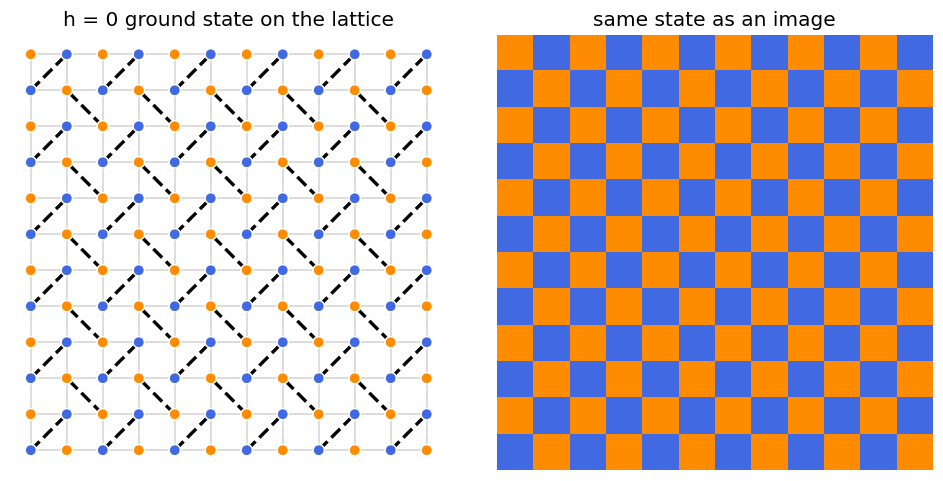

In [7]:
from matplotlib.colors import ListedColormap
SPIN_CMAP = ListedColormap(["darkorange", "white", "royalblue"])   # down / missing / up

def spin_image(spins, L):
    return np.array([spins[i] for i in range(L * L)], float).reshape(L, L)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
draw_lattice(L, J1_bonds, J2_bonds, axes[0], spins=[spins[i] for i in sites])
axes[0].set_title("h = 0 ground state on the lattice")
axes[1].imshow(spin_image(spins, L).T, cmap=SPIN_CMAP, origin="lower", vmin=-1, vmax=1)
axes[1].set_title("same state as an image"); axes[1].axis("off")
plt.tight_layout(); plt.show()

A perfect checkerboard: every square bond (J₁) is happy. But look at the dashed dimers —
both ends are always the *same* colour, so every dimer bond is frustrated. The lattice can't
satisfy both kinds of bond at once, and with J₂ = 1.5 the square bonds win.
(Try `J2 = 3.0` later: then the dimers win instead.) Net magnetization: zero.
Now let's push on it with a field.

## 4. Turning up the field → magnetization plateaus

A normal magnet's magnetization rises smoothly as you increase the field.
A frustrated magnet can lock into special patterns that stay stable over a whole range of fields —
so the magnetization stalls on flat steps: plateaus. SrCu₂(BO₃)₂ is famous for them experimentally.

For each field value we ask the annealer for the ground state and record the average spin:

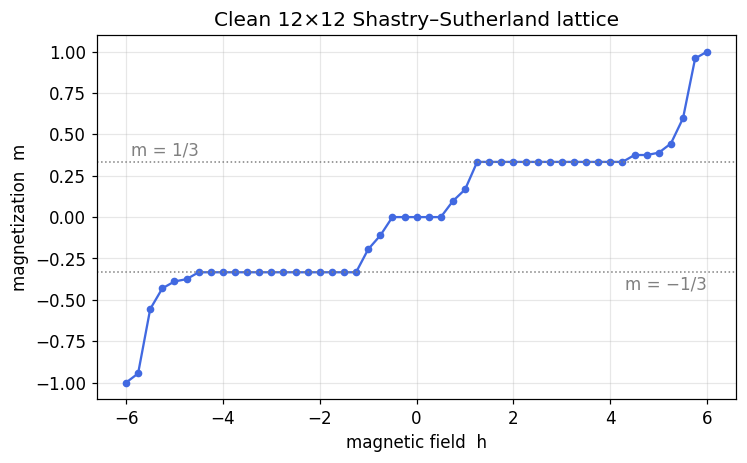

In [8]:
fields = np.linspace(-6, 6, 49)

def magnetization_curve(J1_bonds, J2_bonds, sites):
    return [np.mean(list(ground_state(h, J1_bonds, J2_bonds, sites)[0].values())) for h in fields]

m_clean = magnetization_curve(J1_bonds, J2_bonds, sites)

plt.figure(figsize=(7.5, 4.3))
plt.plot(fields, m_clean, "o-", color="royalblue", ms=4)
for level in (-1/3, 1/3):
    plt.axhline(level, color="grey", ls=":", lw=1)
plt.text(-5.9, 1/3 + 0.04, "m = 1/3", color="grey"); plt.text(4.3, -1/3 - 0.1, "m = −1/3", color="grey")
plt.xlabel("magnetic field  h"); plt.ylabel("magnetization  m")
plt.title("Clean 12×12 Shastry–Sutherland lattice")
plt.grid(alpha=0.3); plt.show()

Clear **staircase**: a plateau at **m = 0**, a wide plateau at **m = 1/3**, then saturation at **m = 1**
(everything up). The 1/3 plateau means exactly 1 in 3 spins effectively points down in a
stable, repeating pattern. Let's see what that pattern looks like:

h = 3.0  ->  m = 0.333


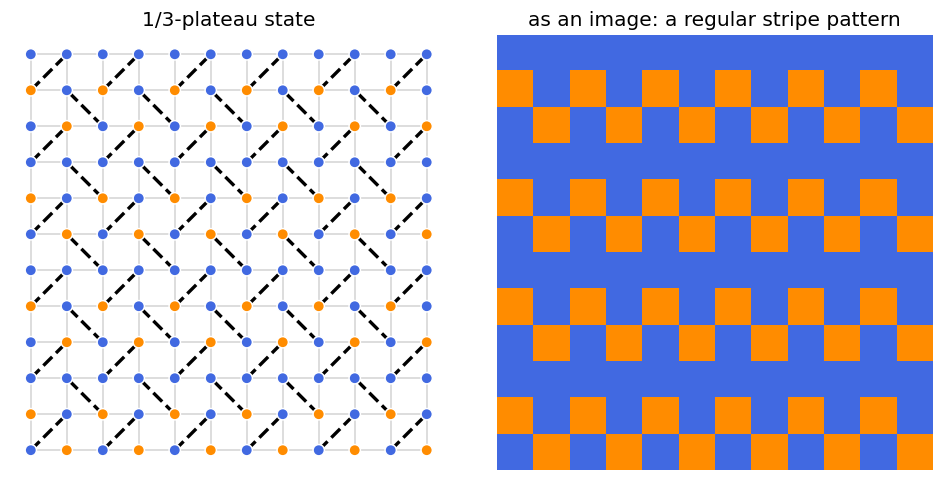

In [9]:
spins_13, _ = ground_state(3.0, J1_bonds, J2_bonds, sites)
print(f"h = 3.0  ->  m = {np.mean(list(spins_13.values())):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
draw_lattice(L, J1_bonds, J2_bonds, axes[0], spins=[spins_13[i] for i in sites])
axes[0].set_title("1/3-plateau state")
axes[1].imshow(spin_image(spins_13, L).T, cmap=SPIN_CMAP, origin="lower", vmin=-1, vmax=1)
axes[1].set_title("as an image: a regular stripe pattern"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## 5. Real materials have defects

Real crystals are never perfect. Two kinds of damage:

* **Site defects** — a magnetic atom is missing (a vacancy)
* **Bond defects** — a coupling between two atoms is broken

Frustrated systems are *very* sensitive to this, because so many states are nearly tied —
a small defect can tip the balance. Let's randomly delete sites and bonds and redo the sweep:

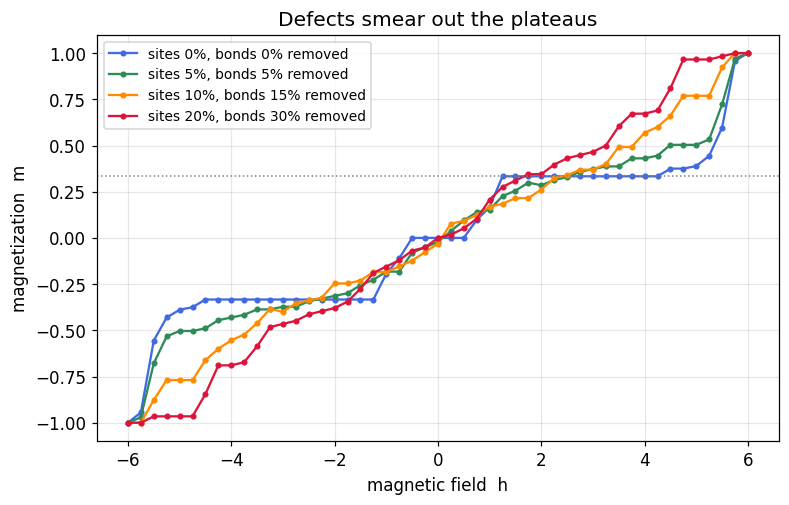

In [10]:
def add_defects(site_frac, bond_frac, seed=0):
    rng = np.random.default_rng(seed)
    removed = set(rng.choice(L * L, int(site_frac * L * L), replace=False))
    keep_site = [i for i in range(L * L) if i not in removed]
    ok = lambda b: b[0] not in removed and b[1] not in removed and rng.random() > bond_frac
    return [b for b in J1_bonds if ok(b)], [b for b in J2_bonds if ok(b)], keep_site

cases = [(0.00, 0.00), (0.05, 0.05), (0.10, 0.15), (0.20, 0.30)]
plt.figure(figsize=(8, 4.8))
for (fs, fb), color in zip(cases, ["royalblue", "seagreen", "darkorange", "crimson"]):
    m = magnetization_curve(*add_defects(fs, fb))
    plt.plot(fields, m, "o-", ms=3, color=color, label=f"sites {fs:.0%}, bonds {fb:.0%} removed")
plt.axhline(1/3, color="grey", ls=":", lw=1)
plt.xlabel("magnetic field  h"); plt.ylabel("magnetization  m")
plt.title("Defects smear out the plateaus"); plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.show()

As the defect concentration grows, the sharp steps titlt and shift
With heavy damage the clean plateau structure is essentially gone.
That's a hint that the type of critical behaviour itself is changing.

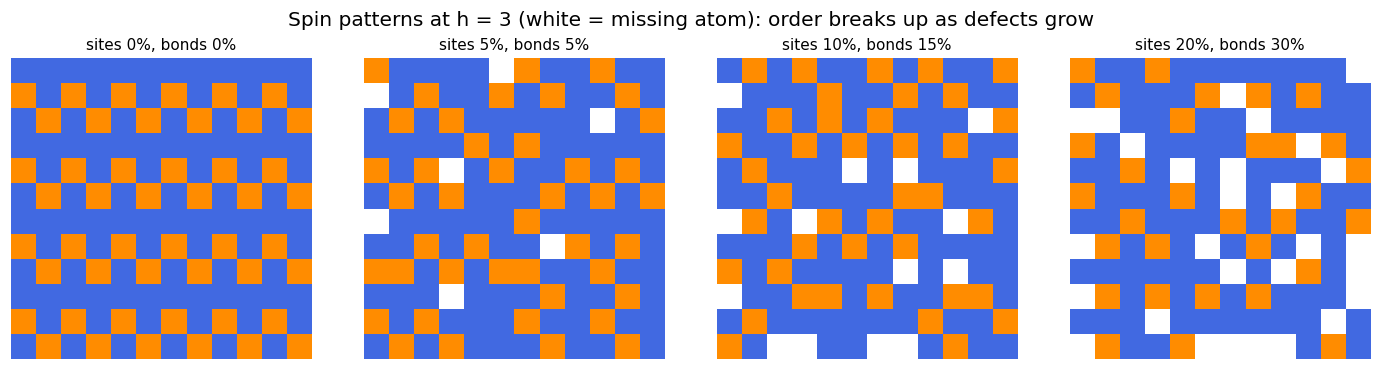

In [11]:
fig, axes = plt.subplots(1, len(cases), figsize=(13, 3.4))
for ax, (fs, fb) in zip(axes, cases):
    b1, b2, keep = add_defects(fs, fb)
    s, _ = ground_state(3.0, b1, b2, keep)
    img = np.zeros((L, L))                                # 0 = missing atom (white)
    for i in keep: img[divmod(i, L)] = s[i]
    ax.imshow(img.T, cmap=SPIN_CMAP, origin="lower", vmin=-1, vmax=1)
    ax.set_title(f"sites {fs:.0%}, bonds {fb:.0%}", fontsize=10); ax.axis("off")
fig.suptitle("Spin patterns at h = 3 (white = missing atom): order breaks up as defects grow")
plt.tight_layout(); plt.show()

## 6. Where this is going: letting machine learning read the pictures

Physicists sort phase transitions into **universality classes** — families that behave the same way
near the transition regardless of microscopic details. Our question: *do enough defects create a new one?*

Those spin-pattern images above are exactly what a machine-learning classifier can learn from.
The plan (ongoing work):

1. Generate many such images with the annealer and with DMRG (a precise classical method) for
   clean and defected lattices
2. Label them by class: **clean 2D Ising**, **random-field Ising**, or **defect-dominated**
3. Train a classifier to recognise the class directly from the spin patterns
4. Move to the D-Wave Advantage 2 QPU to generate data a classical computer struggles with

## Try it yourself

* Change `J2` (try `1.0`, `2.0`, `3.0`) — do the plateaus move or disappear?
* Try different defect fractions or seeds in `cases`
* Swap in the QPU sampler above if you have a Leap account

### References
* P. Kairys *et al.*, *Simulating the Shastry–Sutherland Ising model using quantum annealing*, PRX Quantum **1**, 020320 (2020)
* B. S. Shastry & B. Sutherland, *Exact ground state of a quantum mechanical antiferromagnet*, Physica B+C **108**, 1069 (1981)
* S. Basak *et al.*, *Deep learning Hamiltonians from disordered image data in quantum materials*, Phys. Rev. B **107**, 205121 (2023)
* M. W. Johnson *et al.*, *Quantum annealing with manufactured spins*, Nature **473**, 194 (2011)

